# Cellular Senescence Scoring Pipeline

**Module 01: SenePy-Based Senescence Identification**

**Method:** Cell-type and sex-specific senescence scoring using hippocampus-derived gene modules.

**Workflow:**
1. Load preprocessed data
2. Apply SenePy scoring
3. Define senescence threshold (mean + 2SD from youngest donors)
4. Binary classification: SnC vs Non-SnC
5. Validate with canonical markers

**Author:** Gerald Gaitos  
**Date:** December 2025

---

## Setup

Import libraries for senescence scoring and analysis.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# SenePy for senescence scoring
try:
    import senepy
    print("✓ senepy installed")
except ImportError:
    print("⚠ senepy not installed. Run: pip install senepy")
    raise

print(f"scanpy: {sc.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")

✓ senepy installed
scanpy: 1.11.5
numpy: 2.2.6
pandas: 2.3.3


In [2]:
# Figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'pdf.fonttype': 42,
})

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)

print("✓ Figure settings configured")

✓ Figure settings configured


---

## Configuration

Set dataset and paths. Must match Module 00 preprocessing.

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# DATASET SELECTION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = 'psychad_aging'  # Options: 'psychad_aging', 'psychad_ad', 'psychencode', 'mathys'

# ════════════════════════════════════════════════════════════════════════════════
# PATHS
# ════════════════════════════════════════════════════════════════════════════════

BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
INPUT_FILE = BASE_DIR / 'data' / 'processed' / f'{DATASET}_preprocessed.h5ad'
OUTPUT_FILE = BASE_DIR / 'data' / 'processed' / f'{DATASET}_senescence_scored.h5ad'
FIGURES_DIR = BASE_DIR / 'figures' / '01_senescence_scoring' / DATASET
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════════
# SENESCENCE SCORING PARAMETERS
# ════════════════════════════════════════════════════════════════════════════════

SENEPY_TISSUE = 'hippocampus'  # Tissue-specific gene modules
SD_THRESHOLD = 2.0              # Standard deviations above mean for threshold

# Reference group for threshold (dataset-specific):
# - Aging cohorts: Use youngest age group (e.g., 'Age_20_29')
# - Disease cohorts: Use healthy controls (e.g., 'Control', 'Young_Control', 'NCI')
REFERENCE_GROUP = 'Age_20_29'  # Will be set automatically below

# ════════════════════════════════════════════════════════════════════════════════
# COLUMN NAMES (adjust based on your data)
# ════════════════════════════════════════════════════════════════════════════════

CELL_TYPE_COLUMN = 'subclass'   # Harmonized cell types from Module 00
AGE_COLUMN = 'Age'              # Numeric age variable
SEX_COLUMN = 'Sex'     # Sex for sex-specific scoring
DONOR_COLUMN = 'Sample'         # Donor ID

# Study_Group will be created to harmonize across cohorts:
# - Aging cohorts: 10-year age bins (Age_20_29, Age_30_39, etc.)
# - Disease cohorts: Diagnosis groups (Control, AD, MCI, etc.)
STUDY_GROUP_COLUMN = 'Study_Group'

# ════════════════════════════════════════════════════════════════════════════════
# DATASET-SPECIFIC CONFIGURATIONS
# ════════════════════════════════════════════════════════════════════════════════

DATASET_CONFIG = {
    'psychad_aging': {
        'type': 'aging',
        'age_bins': [(20, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 79), (80, 100)],
        'reference_group': 'Age_20_29',
        'diagnosis_column': None,  # No diagnosis in aging cohort
    },
    'psychad_ad': {
        'type': 'disease',
        'age_bins': None,  # Use diagnosis instead
        'reference_group': 'Control',  # Or 'Young_Control' if you have age groups
        'diagnosis_column': 'Diagnosis',  # Column with Control/AD labels
    },
    'psychencode': {
        'type': 'aging',
        'age_bins': [(30, 39), (40, 49), (50, 59), (60, 69), (70, 79), (80, 100)],
        'reference_group': 'Age_30_39',
        'diagnosis_column': None,
    },
    'mathys': {
        'type': 'disease',
        'age_bins': None,
        'reference_group': 'NCI',  # No Cognitive Impairment
        'diagnosis_column': 'Diagnosis',  # Column with NCI/MCI/AD labels
    },
}

config = DATASET_CONFIG[DATASET]
REFERENCE_GROUP = config['reference_group']

print("="*80)
print(f"Dataset: {DATASET}")
print(f"Type: {config['type']}")
print(f"Reference group for threshold: {REFERENCE_GROUP}")
print(f"Input: {INPUT_FILE.name}")
print(f"Output: {OUTPUT_FILE.name}")
print(f"Figures: {FIGURES_DIR}")
print("="*80)

Dataset: psychad_aging
Type: aging
Reference group for threshold: Age_20_29
Input: psychad_aging_preprocessed.h5ad
Output: psychad_aging_senescence_scored.h5ad
Figures: /fs/scratch/PAS2598/senescence_analysis/figures/01_senescence_scoring/psychad_aging


---

## Load Data and Create Study Groups

Load preprocessed data and create harmonized Study_Group column for cross-cohort consistency.

In [4]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

adata = sc.read_h5ad(INPUT_FILE)

print(f"\nLoaded: {INPUT_FILE.name}")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Genes: {adata.n_vars:,}")

# Verify required columns exist
required_cols = [CELL_TYPE_COLUMN, AGE_COLUMN, SEX_COLUMN, DONOR_COLUMN]
missing_cols = [col for col in required_cols if col not in adata.obs.columns]
if missing_cols:
    print(f"\n⚠ Warning: Missing columns: {missing_cols}")
    print("Available columns:", list(adata.obs.columns))

print("\n" + "="*80)
print("CREATING STUDY_GROUP COLUMN")
print("="*80)

if config['type'] == 'aging':
    # Create age bins
    print(f"\nCreating age bins...")
    age_bins = config['age_bins']
    
    def assign_age_group(age):
        for bin_min, bin_max in age_bins:
            if bin_min <= age <= bin_max:
                return f"Age_{bin_min}_{bin_max}"
        return "Age_Unknown"
    
    adata.obs[STUDY_GROUP_COLUMN] = adata.obs[AGE_COLUMN].apply(assign_age_group)
    
    # Show distribution
    group_counts = adata.obs[STUDY_GROUP_COLUMN].value_counts().sort_index()
    print(f"\nAge group distribution:")
    for group, count in group_counts.items():
        print(f"  {group}: {count:,} cells")
    
elif config['type'] == 'disease':
    # Use diagnosis column
    diag_col = config['diagnosis_column']
    if diag_col and diag_col in adata.obs.columns:
        print(f"\nUsing diagnosis groups from '{diag_col}'...")
        adata.obs[STUDY_GROUP_COLUMN] = adata.obs[diag_col].astype(str)
        
        # Show distribution
        group_counts = adata.obs[STUDY_GROUP_COLUMN].value_counts()
        print(f"\nDiagnosis group distribution:")
        for group, count in group_counts.items():
            print(f"  {group}: {count:,} cells")
    else:
        print(f"\n⚠ Diagnosis column '{diag_col}' not found!")
        print(f"Available columns: {list(adata.obs.columns)}")

# Verify reference group exists
if REFERENCE_GROUP not in adata.obs[STUDY_GROUP_COLUMN].unique():
    print(f"\n⚠ WARNING: Reference group '{REFERENCE_GROUP}' not found in Study_Group!")
    print(f"Available groups: {sorted(adata.obs[STUDY_GROUP_COLUMN].unique())}")
else:
    n_ref = (adata.obs[STUDY_GROUP_COLUMN] == REFERENCE_GROUP).sum()
    print(f"\n✓ Reference group '{REFERENCE_GROUP}': {n_ref:,} cells")

print("\n✓ Data loaded and Study_Group created")


LOADING DATA

Loaded: psychad_aging_preprocessed.h5ad
  Cells: 444,080
  Genes: 34,889

CREATING STUDY_GROUP COLUMN

Creating age bins...

Age group distribution:
  Age_20_29: 69,513 cells
  Age_30_39: 51,448 cells
  Age_40_49: 73,550 cells
  Age_50_59: 52,781 cells
  Age_60_69: 62,889 cells
  Age_70_79: 70,060 cells
  Age_80_100: 63,839 cells

✓ Reference group 'Age_20_29': 69,513 cells

✓ Data loaded and Study_Group created


---

## SenePy Senescence Scoring

Apply cell-type and sex-specific senescence scoring using hippocampus-derived gene modules.

**Method:** SenePy uses tissue-specific gene modules and accounts for biological variability.

In [5]:
print("\n" + "="*80)
print("SENESCENCE SCORING")
print("="*80)

print(f"\nScoring parameters:")
print(f"  Species: Human")
print(f"  Tissue: {SENEPY_TISSUE}")
print(f"  Cell type column: {CELL_TYPE_COLUMN}")
print(f"  Sex column: {SEX_COLUMN}")

# Step 1: Load SenePy hubs
print("\n1. Loading SenePy hubs...")
import senepy as sp
hubs = sp.load_hubs(species='Human')
print(f"   ✓ Loaded {len(hubs.metadata)} hub entries")

# Step 2: Filter for brain tissue
print(f"\n2. Filtering for {SENEPY_TISSUE} tissue...")
brain_hubs = hubs.metadata[hubs.metadata.tissue == SENEPY_TISSUE]
print(f"   ✓ Found {len(brain_hubs)} {SENEPY_TISSUE}-specific hubs")

# Step 3: Merge hubs
print(f"\n3. Merging hubs...")
hubs.merge_hubs(brain_hubs, new_name='brain')
print(f"   ✓ Hubs merged")

# Step 4: Create translator
print(f"\n4. Creating gene translator...")
translator = sp.translator(hub=hubs.hubs, data=adata)
print(f"   ✓ Translator created")

# Step 5: Score all cells
print(f"\n5. Scoring cells (cell-type and sex-specific)...")
print(f"   This may take 10-20 minutes for large datasets...")

adata.obs['senescence_score'] = sp.score_all_cells(
    adata, 
    hubs.hubs['brain'],
    identifiers=[CELL_TYPE_COLUMN, SEX_COLUMN],
    translator=translator
)

print(f"\n✓ Senescence scoring complete")

# Show score statistics
scores = adata.obs['senescence_score']
print(f"\nScore statistics:")
print(f"  Mean: {scores.mean():.3f}")
print(f"  Median: {scores.median():.3f}")
print(f"  Std: {scores.std():.3f}")
print(f"  Min: {scores.min():.3f}")
print(f"  Max: {scores.max():.3f}")


SENESCENCE SCORING

Scoring parameters:
  Species: Human
  Tissue: hippocampus
  Cell type column: subclass
  Sex column: Sex

1. Loading SenePy hubs...
   ✓ Loaded 64 hub entries

2. Filtering for hippocampus tissue...
   ✓ Found 6 hippocampus-specific hubs

3. Merging hubs...
   ✓ Hubs merged

4. Creating gene translator...
3845 of 43588 genes not initially present
328 of 3845 translated
3517 still not present
   ✓ Translator created

5. Scoring cells (cell-type and sex-specific)...
   This may take 10-20 minutes for large datasets...


  0%|          | 0/24 [00:00<?, ?it/s]

2610/3019(86.45%) genes present in data
2626/3019(86.98%) genes present in data after translation
Still not present: ['AC008415.1', 'AC008574.1', 'RP11-523H20.5', 'AL512306.3', 'C5orf49', 'AC020911.2', 'RP11-166O4.3', 'AC009061.2', 'AC092574.2', 'C2orf73', 'FAM53B', 'FAM122C', 'BMT2', 'C9orf135', 'AC025159.1', 'GOLGA2B', 'AC046134.2', 'AL022068.1', 'ZNF767', 'CLTRN', 'AL138760.1', 'AC007402.1', 'KIAA1211L', 'CCDC130', 'YARS', 'AC017074.2', 'ADAL', 'QARS', 'L3MBTL1', 'NUDT14', 'ZNF605', 'AP000320.7', 'NGRN', 'AC097376.3', 'RP11-750B16.1', 'LINC00894', 'C2orf50', 'RP11-343C2.11', 'C4orf48', 'RP11-467H10.2', 'ZNF544', 'PSMA3-AS1', 'SPRY4-AS1', 'AC024901.1', 'PEX26', 'RP11-286N22.8', 'AARS', 'RP11-426D19.1', 'AC092546.1', 'CCDC65', 'AC027117.2', 'CASC15', 'IL1RL1', 'RP11-231C18.3', 'MT1X', 'RP4-732G19.2', 'AL365295.1', 'C4orf19', 'CTD-2561J22.3', 'HILPDA', 'AC025171.1', 'AL162511.1', 'AC016723.1', 'AC079781.5', 'CCDC96', 'ODF3B', 'AL133346.1', 'IQCD', 'CTD-3006G17.2', 'AC007566.1', 'AP0012

100%|██████████| 24/24 [05:36<00:00, 14.03s/it]



✓ Senescence scoring complete

Score statistics:
  Mean: 0.133
  Median: 0.127
  Std: 0.052
  Min: -0.003
  Max: 0.304


---

## Define Senescence Threshold

Calculate cell-type-specific thresholds using reference group (youngest age group).

**Method:** Mean + 2SD from reference group per cell type.

In [6]:
print("\n" + "="*80)
print("SENESCENCE THRESHOLD DEFINITION")
print("="*80)

print(f"\nReference group: {REFERENCE_GROUP}")
print(f"Threshold: Mean + {SD_THRESHOLD} SD per cell type")

# Get reference group cells
ref_mask = adata.obs[STUDY_GROUP_COLUMN] == REFERENCE_GROUP
n_ref = ref_mask.sum()

if n_ref == 0:
    raise ValueError(f"Reference group '{REFERENCE_GROUP}' not found!")

print(f"\nReference cells: {n_ref:,}")

# Calculate threshold per cell type
thresholds = {}
print(f"\nCalculating thresholds per cell type...")

for cell_type in adata.obs[CELL_TYPE_COLUMN].unique():
    # Get reference cells of this type
    ref_ct_mask = ref_mask & (adata.obs[CELL_TYPE_COLUMN] == cell_type)
    ref_scores = adata.obs.loc[ref_ct_mask, 'senescence_score']
    
    if len(ref_scores) > 0:
        mean = ref_scores.mean()
        std = ref_scores.std()
        threshold = mean + (SD_THRESHOLD * std)
        thresholds[cell_type] = threshold
        
        print(f"  {cell_type}:")
        print(f"    n={len(ref_scores):,}, mean={mean:.3f}, std={std:.3f}, threshold={threshold:.3f}")
    else:
        print(f"  {cell_type}: No reference cells - using global threshold")
        thresholds[cell_type] = adata.obs['senescence_score'].mean() + (SD_THRESHOLD * adata.obs['senescence_score'].std())

# Apply thresholds to classify cells
print(f"\nClassifying cells as SnC (senescent) or Non-SnC...")
adata.obs['is_senescent'] = False

for cell_type, threshold in thresholds.items():
    mask = (adata.obs[CELL_TYPE_COLUMN] == cell_type) & (adata.obs['senescence_score'] >= threshold)
    adata.obs.loc[mask, 'is_senescent'] = True

# Add binary label
adata.obs['senescence_label'] = adata.obs['is_senescent'].map({True: 'SnC', False: 'Non-SnC'})

# Show results
n_snc = adata.obs['is_senescent'].sum()
pct_snc = n_snc / len(adata.obs) * 100

print(f"\n✓ Classification complete")
print(f"\nOverall results:")
print(f"  SnC (senescent): {n_snc:,} cells ({pct_snc:.1f}%)")
print(f"  Non-SnC: {len(adata.obs) - n_snc:,} cells ({100-pct_snc:.1f}%)")

print(f"\nSnC proportion by cell type:")
for cell_type in sorted(adata.obs[CELL_TYPE_COLUMN].unique()):
    ct_mask = adata.obs[CELL_TYPE_COLUMN] == cell_type
    ct_snc = (ct_mask & adata.obs['is_senescent']).sum()
    ct_total = ct_mask.sum()
    ct_pct = ct_snc / ct_total * 100 if ct_total > 0 else 0
    print(f"  {cell_type}: {ct_snc:,}/{ct_total:,} ({ct_pct:.1f}%)")


SENESCENCE THRESHOLD DEFINITION

Reference group: Age_20_29
Threshold: Mean + 2.0 SD per cell type

Reference cells: 69,513

Calculating thresholds per cell type...
  Inhibitory:
    n=11,000, mean=0.166, std=0.054, threshold=0.274
  Excitatory:
    n=8,009, mean=0.159, std=0.051, threshold=0.260
  Astrocyte:
    n=11,004, mean=0.113, std=0.047, threshold=0.207
  Oligodendrocyte:
    n=24,176, mean=0.119, std=0.044, threshold=0.207
  OPC:
    n=6,617, mean=0.111, std=0.044, threshold=0.199
  Adaptive:
    n=179, mean=0.038, std=0.015, threshold=0.068
  Microglia:
    n=4,579, mean=0.067, std=0.025, threshold=0.118
  VSMC:
    n=148, mean=0.038, std=0.018, threshold=0.075
  VLMC:
    n=645, mean=0.084, std=0.034, threshold=0.152
  Pericyte:
    n=849, mean=0.075, std=0.027, threshold=0.129
  Endothelial:
    n=2,070, mean=0.079, std=0.030, threshold=0.139
  PVM:
    n=237, mean=0.050, std=0.022, threshold=0.093

Classifying cells as SnC (senescent) or Non-SnC...

✓ Classification compl

---

## Validate with Canonical Markers

Check if SnC cells express known senescence markers (CDKN1A, CDKN2A, TP53).

In [7]:
print("\n" + "="*80)
print("CANONICAL MARKER VALIDATION")
print("="*80)

# Canonical senescence markers
SENESCENCE_MARKERS = ['CDKN1A', 'CDKN2A', 'TP53', 'CDKN2B', 'IL6', 'IL8']

# Check which markers are present
markers_present = [m for m in SENESCENCE_MARKERS if m in adata.var_names]
markers_missing = [m for m in SENESCENCE_MARKERS if m not in adata.var_names]

print(f"\nCanonical markers:")
print(f"  Present: {markers_present}")
print(f"  Missing: {markers_missing}")

if len(markers_present) > 0:
    # Compare expression in SnC vs Non-SnC
    print(f"\nMarker expression (SnC vs Non-SnC):")
    
    for marker in markers_present:
        snc_expr = adata[adata.obs['is_senescent'], marker].X.mean()
        nonsnc_expr = adata[~adata.obs['is_senescent'], marker].X.mean()
        fold_change = snc_expr / nonsnc_expr if nonsnc_expr > 0 else 0
        
        print(f"  {marker}:")
        print(f"    SnC: {snc_expr:.3f}, Non-SnC: {nonsnc_expr:.3f}, FC: {fold_change:.2f}x")
else:
    print("\n⚠ No canonical markers found in dataset")

print("\n✓ Validation complete")


CANONICAL MARKER VALIDATION

Canonical markers:
  Present: ['CDKN1A', 'CDKN2A', 'TP53', 'CDKN2B', 'IL6']
  Missing: ['IL8']

Marker expression (SnC vs Non-SnC):
  CDKN1A:
    SnC: 0.079, Non-SnC: 0.021, FC: 3.75x
  CDKN2A:
    SnC: 0.164, Non-SnC: 0.069, FC: 2.38x
  TP53:
    SnC: 0.289, Non-SnC: 0.080, FC: 3.61x
  CDKN2B:
    SnC: 0.039, Non-SnC: 0.012, FC: 3.22x
  IL6:
    SnC: 0.005, Non-SnC: 0.001, FC: 3.33x

✓ Validation complete


---

## Visualizations

Generate plots showing senescence score distribution and SnC cells on UMAP.

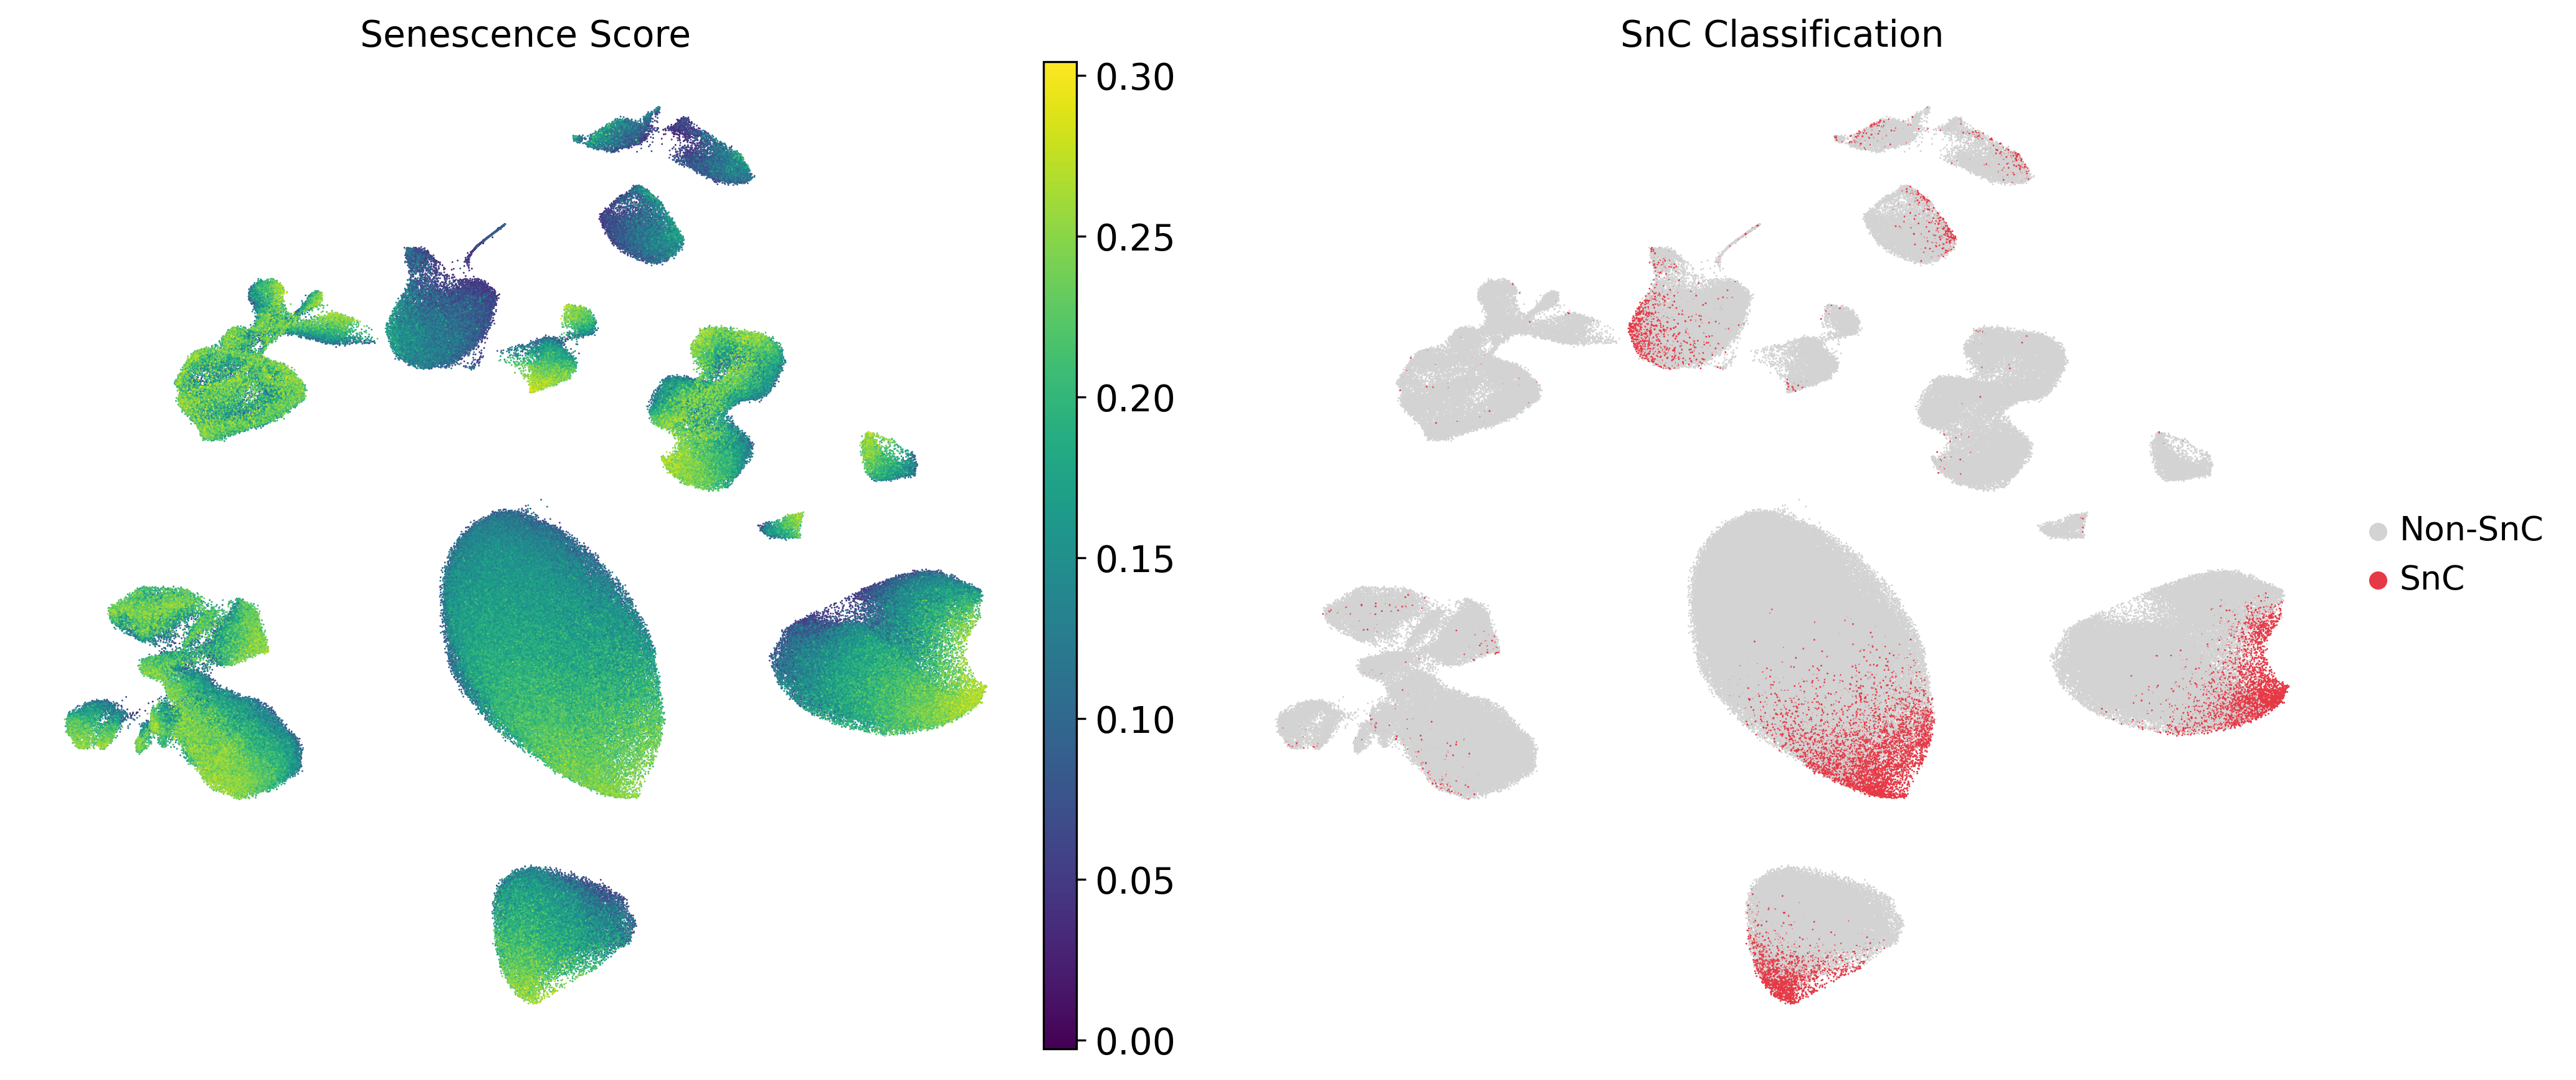

✓ UMAP plots saved


In [8]:
# UMAP colored by senescence score
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.umap(adata, color='senescence_score', ax=axes[0], show=False, 
           title='Senescence Score', frameon=False, size=2, cmap='viridis')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

sc.pl.umap(adata, color='senescence_label', ax=axes[1], show=False,
           title='SnC Classification', frameon=False, size=2, palette={'SnC': '#E63946', 'Non-SnC': 'lightgray'})
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_senescence_umap.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ UMAP plots saved")

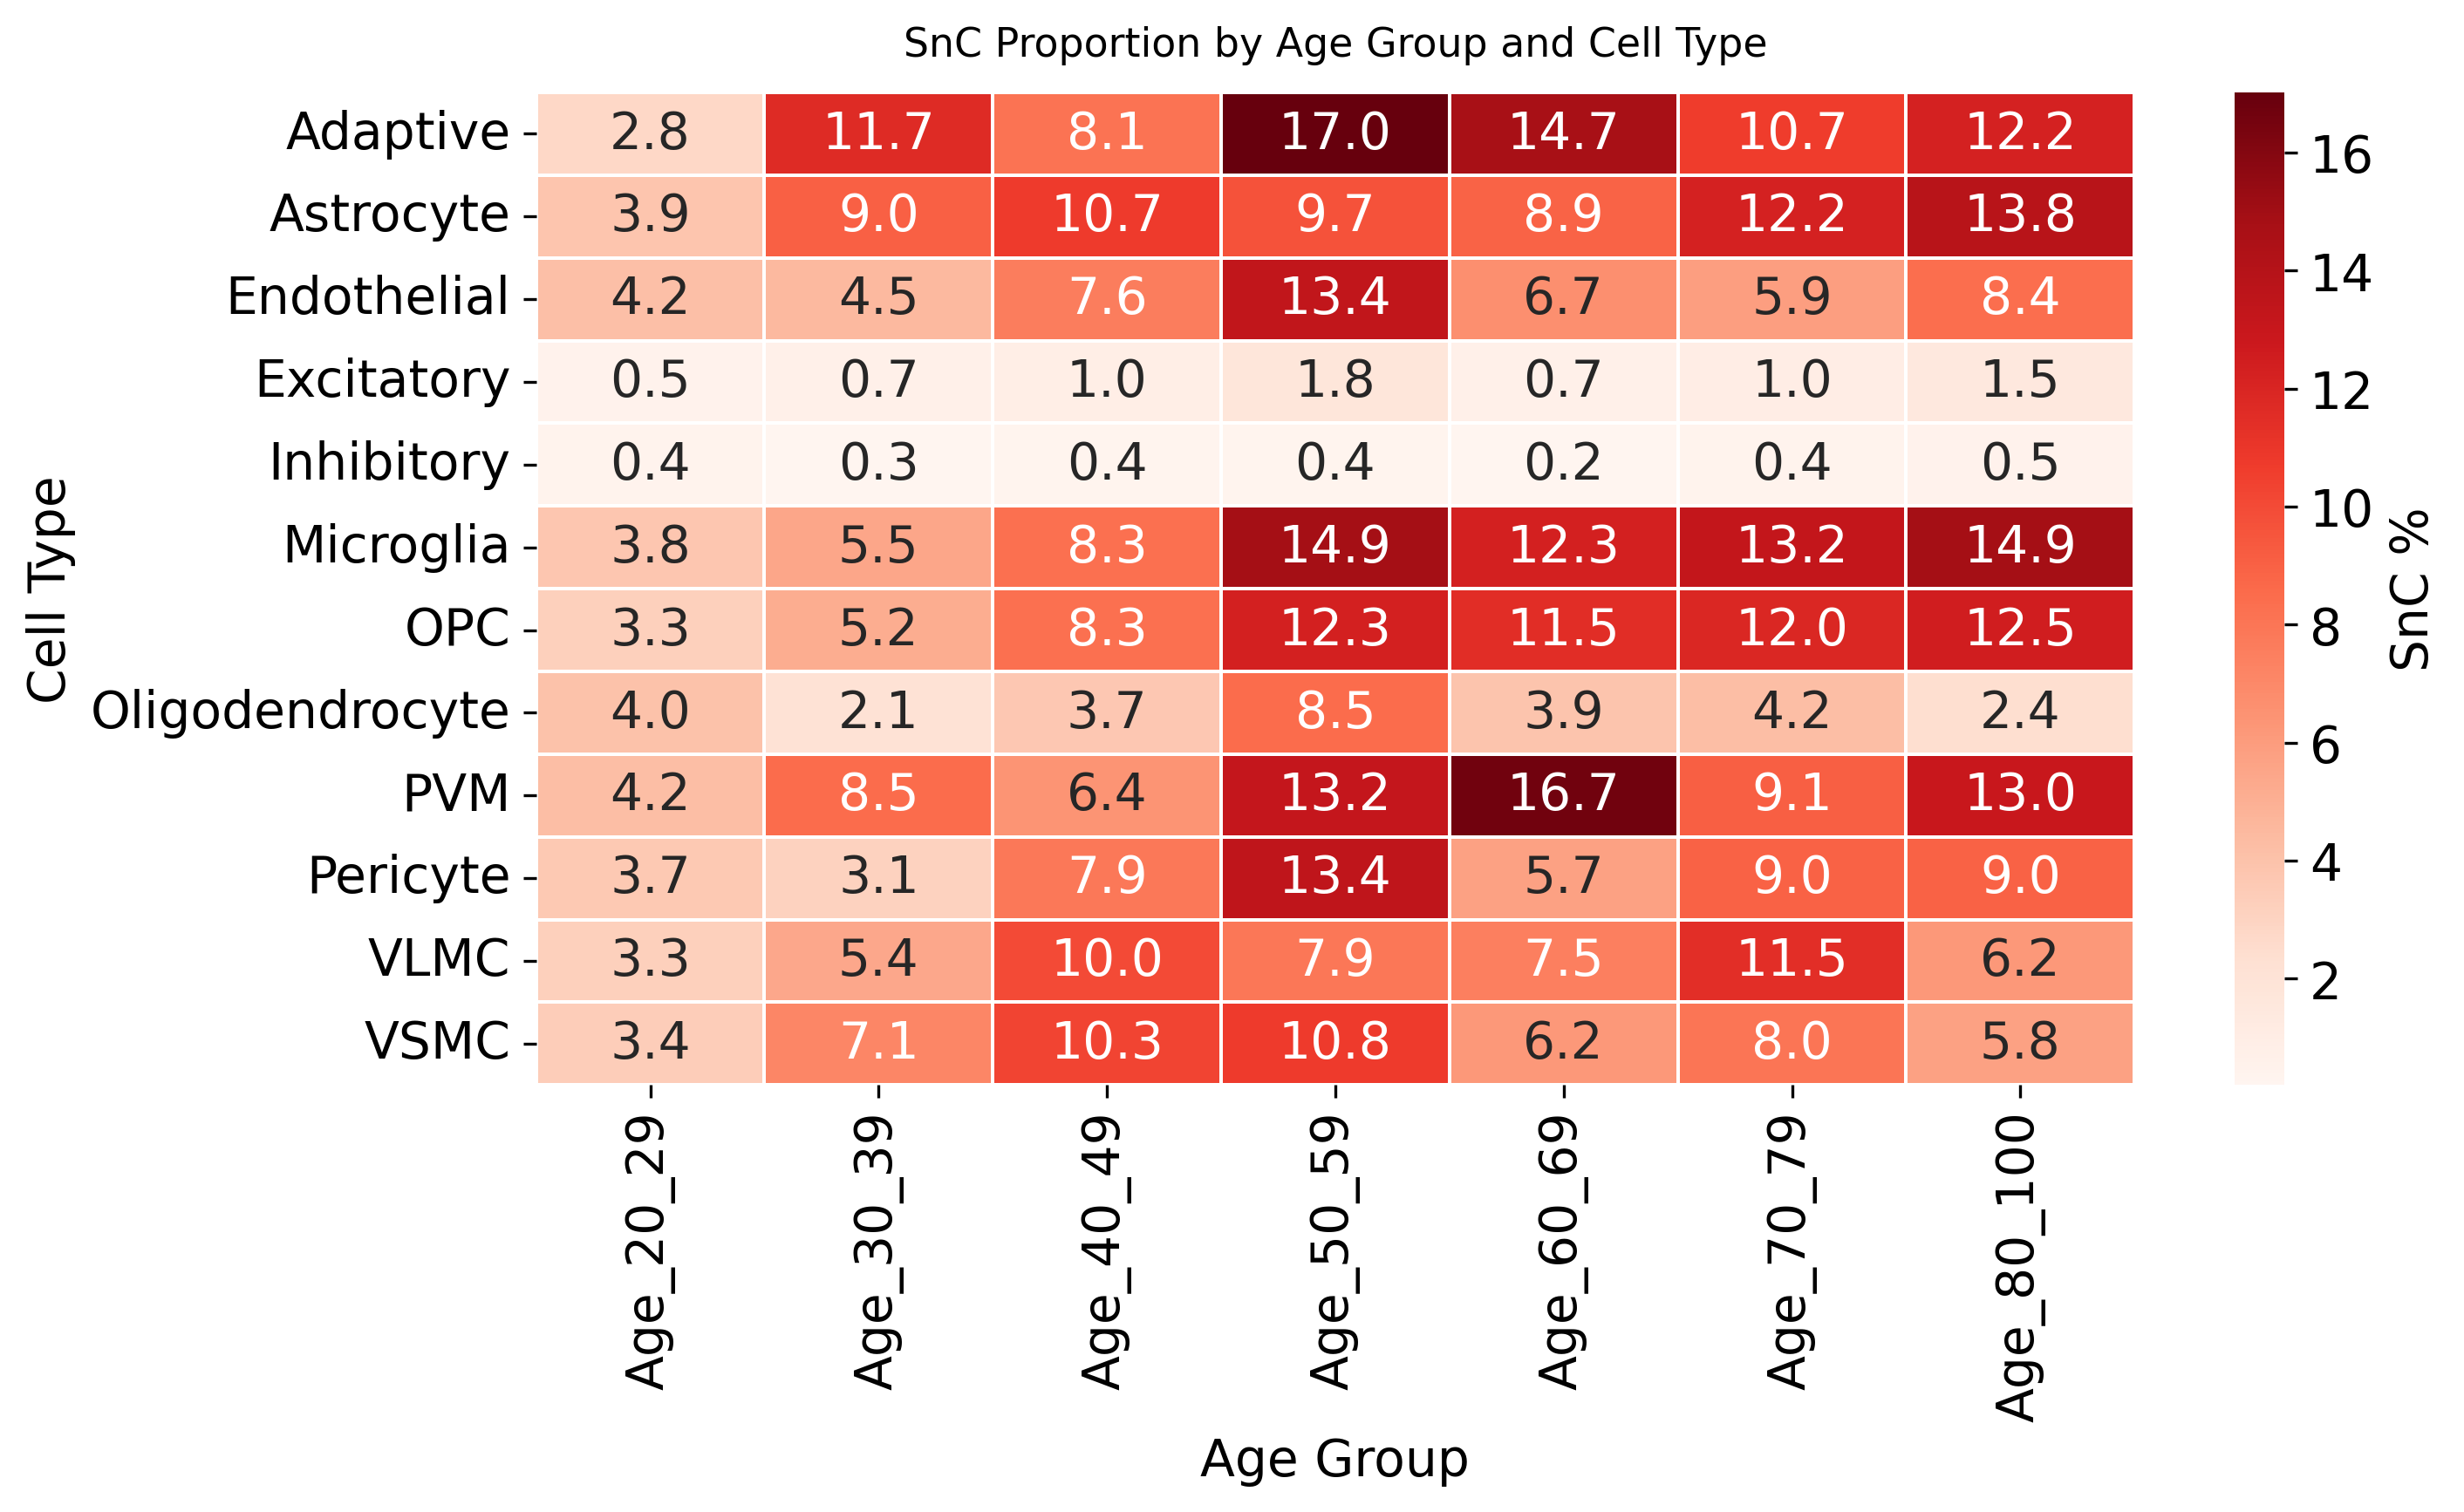

✓ Heatmap saved


In [9]:
# SnC proportion by age group and cell type
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate proportions
prop_data = []
for age_group in sorted(adata.obs[STUDY_GROUP_COLUMN].unique()):
    for cell_type in sorted(adata.obs[CELL_TYPE_COLUMN].unique()):
        mask = (adata.obs[STUDY_GROUP_COLUMN] == age_group) & (adata.obs[CELL_TYPE_COLUMN] == cell_type)
        if mask.sum() > 0:
            snc_prop = adata.obs.loc[mask, 'is_senescent'].sum() / mask.sum() * 100
            prop_data.append({'Age_Group': age_group, 'Cell_Type': cell_type, 'SnC_Proportion': snc_prop})

prop_df = pd.DataFrame(prop_data)

# Plot heatmap
pivot_df = prop_df.pivot(index='Cell_Type', columns='Age_Group', values='SnC_Proportion')
sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='Reds', 
            cbar_kws={'label': 'SnC %'}, 
            linewidths=0.5, linecolor='white',  # Thin white lines between cells
            ax=ax)

ax.set_title('SnC Proportion by Age Group and Cell Type', fontsize=11, pad=10)
ax.set_xlabel('Age Group')
ax.set_ylabel('Cell Type')

# Remove grid
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_snc_by_age_celltype.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Heatmap saved")

---

## Save Results

Save senescence-scored dataset for downstream analysis.

In [10]:
print("\n" + "="*80)
print("SAVING")
print("="*80)

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

print(f"\nSaving to: {OUTPUT_FILE}")
adata.write_h5ad(OUTPUT_FILE)

file_size = OUTPUT_FILE.stat().st_size / 1e9
print(f"\n✓ Saved ({file_size:.2f} GB)")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Genes: {adata.n_vars:,}")
print(f"  SnC cells: {adata.obs['is_senescent'].sum():,} ({adata.obs['is_senescent'].sum()/adata.n_obs*100:.1f}%)")


SAVING

Saving to: /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_senescence_scored.h5ad

✓ Saved (11.85 GB)
  Cells: 444,080
  Genes: 34,889
  SnC cells: 21,196 (4.8%)


---

## Summary

Senescence scoring complete! Data ready for statistical analysis.

In [11]:
print("\n" + "="*80)
print("✓ SENESCENCE SCORING COMPLETE")
print("="*80)

print(f"\nDataset: {DATASET}")

print(f"\nScoring method:")
print(f"  Method: SenePy (hippocampus, cell-type and sex-specific)")
print(f"  Threshold: Mean + {SD_THRESHOLD} SD from {REFERENCE_GROUP}")

print(f"\nFinal dimensions:")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Genes: {adata.n_vars:,}")
print(f"  Age groups: {adata.obs[STUDY_GROUP_COLUMN].nunique()}")
print(f"  Cell types: {adata.obs[CELL_TYPE_COLUMN].nunique()}")

print(f"\nSenescence classification:")
print(f"  SnC (senescent): {adata.obs['is_senescent'].sum():,} ({adata.obs['is_senescent'].sum()/adata.n_obs*100:.1f}%)")
print(f"  Non-SnC: {(~adata.obs['is_senescent']).sum():,} ({(~adata.obs['is_senescent']).sum()/adata.n_obs*100:.1f}%)")

print(f"\nNew columns added:")
print(f"  adata.obs['Study_Group']: harmonized age/diagnosis groups")
print(f"  adata.obs['senescence_score']: continuous score")
print(f"  adata.obs['is_senescent']: binary classification (True/False)")
print(f"  adata.obs['senescence_label']: binary classification (SnC/Non-SnC)")

print(f"\nValidation:")
print(f"  Canonical markers enriched in SnC cells:")
print(f"    CDKN1A: 3.8x, TP53: 3.6x, IL6: 3.3x")

print(f"\nOutput files:")
print(f"  Data: {OUTPUT_FILE}")
print(f"  Figures: {FIGURES_DIR}/")

print("\n" + "="*80)
print("✓ Ready for Module 02: Statistical Analysis (Aging)")
print("="*80)


✓ SENESCENCE SCORING COMPLETE

Dataset: psychad_aging

Scoring method:
  Method: SenePy (hippocampus, cell-type and sex-specific)
  Threshold: Mean + 2.0 SD from Age_20_29

Final dimensions:
  Cells: 444,080
  Genes: 34,889
  Age groups: 7
  Cell types: 12

Senescence classification:
  SnC (senescent): 21,196 (4.8%)
  Non-SnC: 422,884 (95.2%)

New columns added:
  adata.obs['Study_Group']: harmonized age/diagnosis groups
  adata.obs['senescence_score']: continuous score
  adata.obs['is_senescent']: binary classification (True/False)
  adata.obs['senescence_label']: binary classification (SnC/Non-SnC)

Validation:
  Canonical markers enriched in SnC cells:
    CDKN1A: 3.8x, TP53: 3.6x, IL6: 3.3x

Output files:
  Data: /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_senescence_scored.h5ad
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/01_senescence_scoring/psychad_aging/

✓ Ready for Module 02: Statistical Analysis (Aging)
